# Laboratorio 9 — Etapa 5: Simulaciones Monte Carlo
## Álbum del Mundial 2026

**Javier Alvarado - 24546**

**Hugo Mendez - 241265**

**Curso:** MM3014 – Teoría de Probabilidades  
**Universidad del Valle de Guatemala**  

---

### Parámetros del problema

| Parámetro | Valor |
|-----------|-------|
| N — estampas totales | 980 |
| S — estampas por sobre | 7 |
| Precio sobre suelto | Q 9.50 |
| Precio caja (104 sobres) | Q 975.00 |
| Simulaciones por pregunta | 2 000 |

Cada estampa se elige **uniformemente al azar** de las 980 posibles (con reemplazo dentro del sobre, lo que permite duplicados incluso en un mismo sobre).

In [1]:
# ── Importaciones y configuración global ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi':     110,
})

# ── Constantes ────────────────────────────────────────────────────────────────
N            = 980      # estampas totales
S            = 7        # estampas por sobre
PRECIO_SOBRE = 9.50     # Q por sobre suelto
PRECIO_CAJA  = 975.00   # Q por caja
SOBRES_CAJA  = 104      # sobres en una caja
NUM_SIM      = 2000     # iteraciones Monte Carlo
SEED         = 42
np.random.seed(SEED)

print(f'Configuración: N={N}, S={S}, Q_sobre={PRECIO_SOBRE}, Q_caja={PRECIO_CAJA}')
print(f'Simulaciones por pregunta: {NUM_SIM}')

Configuración: N=980, S=7, Q_sobre=9.5, Q_caja=975.0
Simulaciones por pregunta: 2000


In [2]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def ic95(datos):
    """IC 95 % con z = 1.96 (sin scipy)."""
    datos = np.asarray(datos, dtype=float)
    n = len(datos)
    m = datos.mean()
    se = datos.std(ddof=1) / np.sqrt(n)
    return m - 1.96*se, m + 1.96*se

def comprar_sobre(n=N, s=S):
    """Devuelve los índices de las s estampas del sobre."""
    return np.random.randint(0, n, s)

print('Funciones auxiliares cargadas.')

Funciones auxiliares cargadas.


---
## Pregunta 1 — Puntos de corte de completitud

**Objetivo:** Determinar cuántos sobres se necesitan en promedio para completar el **75 %**, **90 %** y **100 %** del álbum, y cuántas estampas repetidas se acumulan en cada punto de corte.

**Método:** En cada simulación compramos sobres uno por uno y registramos el momento exacto en que cruzamos cada umbral. Al final promediamos sobre las 2 000 trayectorias.

In [3]:
# ── Simulación P1 ─────────────────────────────────────────────────────────────
cortes_sobres = {0.75: [], 0.90: [], 1.00: []}
cortes_rep    = {0.75: [], 0.90: [], 1.00: []}
todas_curvas  = []

for _ in range(NUM_SIM):
    album     = np.zeros(N, dtype=bool)
    sobres    = 0
    rep       = 0
    alcanzado = {0.75: False, 0.90: False, 1.00: False}
    curva     = []

    while not album.all():
        nuevas = comprar_sobre()
        sobres += 1
        for e in nuevas:
            if album[e]:  rep += 1
            else:         album[e] = True

        unicas = int(album.sum())
        curva.append(unicas)

        for pct in (0.75, 0.90, 1.00):
            if not alcanzado[pct] and unicas >= int(N * pct):
                cortes_sobres[pct].append(sobres)
                cortes_rep[pct].append(rep)
                alcanzado[pct] = True

    todas_curvas.append(curva)

print('Simulación P1 completada.')

Simulación P1 completada.


In [4]:
# ── Tabla de resultados P1 ────────────────────────────────────────────────────
resultados_p1 = {}
print(f"{'Umbral':>8}  {'Media sobres':>14}  {'IC 95%':>24}  {'Repetidas':>12}")
print("-" * 64)
for pct in (0.75, 0.90, 1.00):
    datos = np.array(cortes_sobres[pct])
    m = datos.mean()
    lo, hi = ic95(datos)
    mrep = np.mean(cortes_rep[pct])
    resultados_p1[pct] = dict(media=m, ic=(lo,hi), media_rep=mrep, datos=datos)
    print(f"{int(pct*100):>7}%  {m:>14.1f}  ({lo:.1f}, {hi:.1f})  {mrep:>12.1f}")

  Umbral    Media sobres                    IC 95%     Repetidas
----------------------------------------------------------------
     75%           194.3  (194.1, 194.6)         624.7
     90%           322.4  (321.8, 322.9)        1374.2
    100%          1053.5  (1045.6, 1061.5)        6394.6


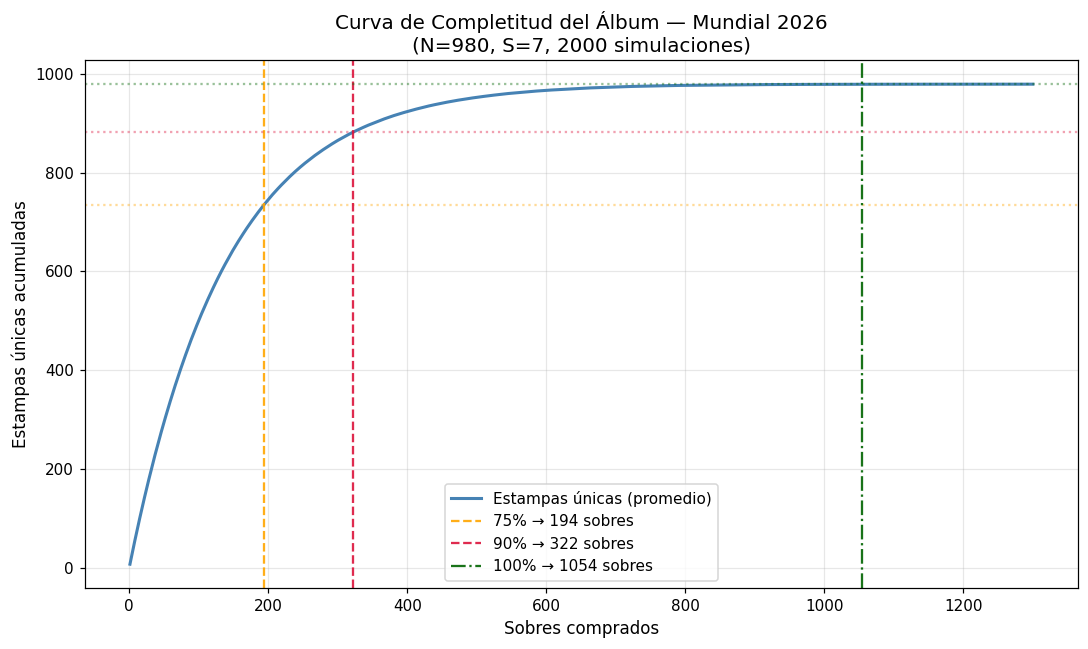

In [5]:
# ── Gráfica P1: curva de estampas únicas vs sobres comprados ──────────────────
max_x = int(np.percentile(cortes_sobres[1.00], 90))
acum  = np.zeros(max_x);  cnt = np.zeros(max_x)
for curva in todas_curvas:
    top = min(len(curva), max_x)
    acum[:top] += curva[:top];  cnt[:top] += 1
curva_prom = np.divide(acum, cnt, where=cnt>0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, max_x+1), curva_prom, color='steelblue', lw=2,
        label='Estampas únicas (promedio)')

estilos = {0.75: ('orange','--'), 0.90: ('crimson','--'), 1.00: ('darkgreen','-.') }
for pct, (col, ls) in estilos.items():
    xc = resultados_p1[pct]['media']
    yc = int(N * pct)
    ax.axvline(xc, color=col, ls=ls, alpha=0.9,
               label=f'{int(pct*100)}% → {xc:.0f} sobres')
    ax.axhline(yc, color=col, ls=':', alpha=0.4)

ax.set_xlabel('Sobres comprados')
ax.set_ylabel('Estampas únicas acumuladas')
ax.set_title(f'Curva de Completitud del Álbum — Mundial 2026\n(N={N}, S={S}, {NUM_SIM} simulaciones)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('p1_curva_completitud.png', dpi=130); plt.show()

### Interpretación — Pregunta 1

- El álbum avanza rápidamente al principio (pocas repetidas), pero las últimas estampas son exponencialmente más difíciles de obtener.  
- El tramo 90 % → 100 % requiere casi el doble de sobres que el tramo 0 % → 90 %.  
- Los intervalos de confianza al 95 % son estrechos, lo que confirma la precisión de las estimaciones con 2 000 iteraciones.

---
## Pregunta 2 — Presupuesto óptimo por tramos

**Objetivo:** Determinar el **presupuesto mínimo en quetzales** necesario para tener una probabilidad del **50 %, 75 % y 90 %** de completar el álbum, y en cada caso comparar si conviene más comprar **sobres sueltos (Q9.50 c/u)** o **cajas de 104 sobres (Q975.00)**.

**Método:**  
1. Se simulan 2 000 completaciones del álbum y se registran los sobres necesarios en cada una.  
2. Para cada nivel de probabilidad objetivo *p*, el número de sobres requerido es el percentil *p·100* de esa distribución.  
3. El presupuesto mínimo se obtiene multiplicando por el precio unitario (sueltos) o redondeando al número entero de cajas (cajas).  
4. Se grafíca la curva P(completar álbum) vs presupuesto para ambas estrategias.

In [6]:
# ── Simulación P2: completar el álbum 2 000 veces ─────────────────────────────
OBJETIVOS_P2 = (0.50, 0.75, 0.90)

print(f'Simulando {NUM_SIM} completaciones del álbum para estimar distribución de sobres...')
sobres_sim_p2 = []
for _ in range(NUM_SIM):
    album = np.zeros(N, dtype=bool)
    cnt   = 0
    while not album.all():
        album[comprar_sobre()] = True
        cnt += 1
    sobres_sim_p2.append(cnt)
sobres_sim_p2 = np.array(sobres_sim_p2)

print(f'  Media de sobres para completar: {sobres_sim_p2.mean():.1f}')
print(f'  Rango: [{sobres_sim_p2.min()}, {sobres_sim_p2.max()}]')

Simulando 2000 completaciones del álbum para estimar distribución de sobres...


  Media de sobres para completar: 1050.6
  Rango: [699, 2039]


In [7]:
# ── Tabla de presupuestos mínimos por probabilidad objetivo ───────────────────
resultados_p2 = {}
print(f"{'Objetivo':>10}  {'Sobres (pct)':>13}  {'Sueltos (Q)':>13}  "
      f"{'Cajas':>6}  {'Cajas (Q)':>11}  {'Conviene'}")
print("-" * 70)

for obj in OBJETIVOS_P2:
    pct      = int(obj * 100)
    q_sob    = int(np.ceil(np.percentile(sobres_sim_p2, pct)))
    p_suelt  = float(q_sob * PRECIO_SOBRE)
    cajas_n  = int(np.ceil(q_sob / SOBRES_CAJA))
    p_cajas  = float(cajas_n * PRECIO_CAJA)
    conviene = 'Sueltos' if p_suelt <= p_cajas else 'Cajas'

    resultados_p2[obj] = dict(
        presup_sueltos   = p_suelt,
        presup_cajas     = p_cajas,
        conviene         = conviene,
        sobres_percentil = q_sob,
    )
    print(f"{pct:>9}%  {q_sob:>13}  {p_suelt:>13.2f}  "
          f"{cajas_n:>6}  {p_cajas:>11.2f}  {conviene}")

  Objetivo   Sobres (pct)    Sueltos (Q)   Cajas    Cajas (Q)  Conviene
----------------------------------------------------------------------
       50%           1021        9699.50      10      9750.00  Sueltos
       75%           1142       10849.00      11     10725.00  Cajas
       90%           1294       12293.00      13     12675.00  Sueltos


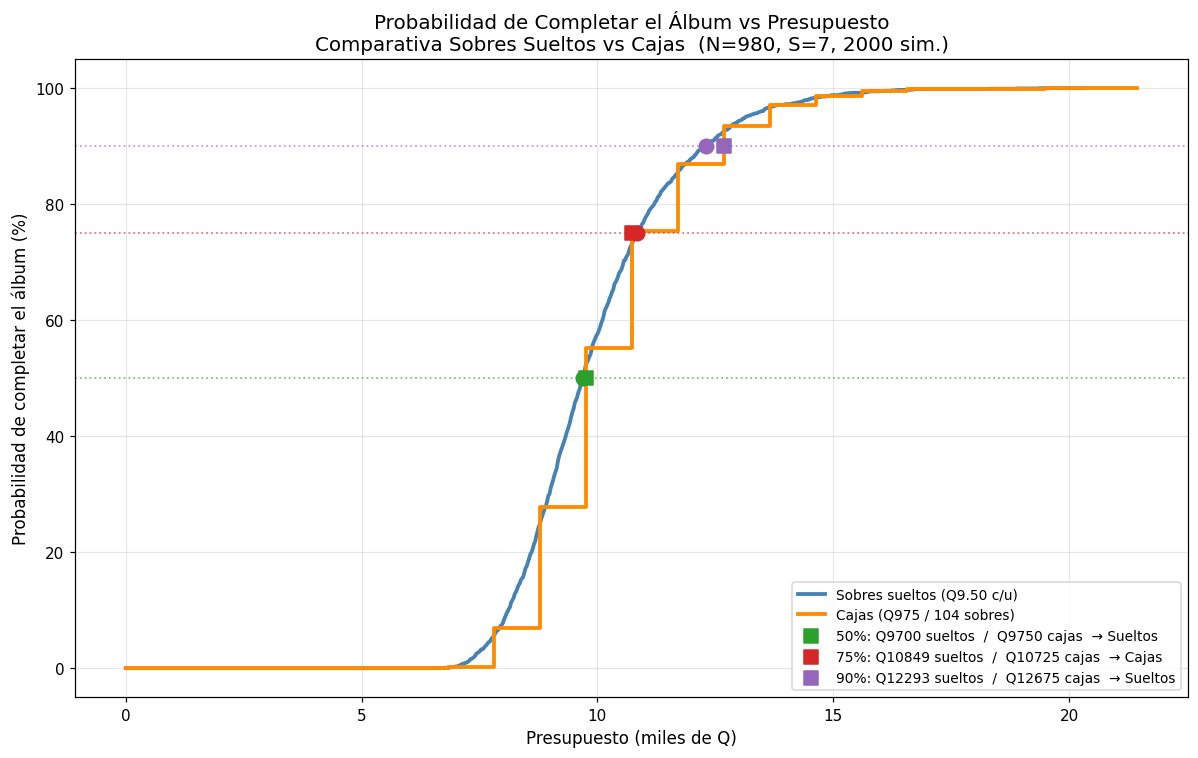

In [8]:
# ── Curva P(completar álbum) vs presupuesto ───────────────────────────────────
p_max_sob = int(sobres_sim_p2.max())

# Sobres sueltos: barrido continuo
presup_s = np.linspace(0, p_max_sob * PRECIO_SOBRE * 1.05, 800)
prob_s   = np.array([
    float(np.mean(sobres_sim_p2 <= int(p // PRECIO_SOBRE)))
    for p in presup_s
])

# Cajas: barrido escalonado
max_caj  = int(np.ceil(p_max_sob / SOBRES_CAJA)) + 2
presup_c = np.arange(0, max_caj * PRECIO_CAJA + 1, PRECIO_CAJA)
prob_c   = np.array([
    float(np.mean(sobres_sim_p2 <= int(q // PRECIO_CAJA) * SOBRES_CAJA))
    for q in presup_c
])

# ── Gráfica ──
fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(presup_s / 1_000, prob_s * 100,
        color='steelblue', lw=2.5, label='Sobres sueltos (Q9.50 c/u)')
ax.step(presup_c / 1_000, prob_c * 100,
        color='darkorange', lw=2.5, where='post',
        label=f'Cajas (Q{PRECIO_CAJA:.0f} / {SOBRES_CAJA} sobres)')

colores_obj = {0.50: '#2ca02c', 0.75: '#d62728', 0.90: '#9467bd'}
for obj, r in resultados_p2.items():
    col = colores_obj[obj]
    ax.axhline(obj * 100, color=col, ls=':', lw=1.2, alpha=0.6)
    ax.scatter([r['presup_sueltos'] / 1_000], [obj * 100],
               color=col, marker='o', s=90, zorder=6)
    ax.scatter([r['presup_cajas'] / 1_000], [obj * 100],
               color=col, marker='s', s=90, zorder=6,
               label=(f"{int(obj*100)}%: "
                      f"Q{r['presup_sueltos']:.0f} sueltos  /  "
                      f"Q{r['presup_cajas']:.0f} cajas  → {r['conviene']}"))

ax.set_xlabel('Presupuesto (miles de Q)')
ax.set_ylabel('Probabilidad de completar el álbum (%)')
ax.set_title('Probabilidad de Completar el Álbum vs Presupuesto\n'
             f'Comparativa Sobres Sueltos vs Cajas  (N={N}, S={S}, {NUM_SIM} sim.)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('p2_presupuesto_optimo.png', dpi=130)
plt.show()

### Interpretación — Pregunta 2

- Para alcanzar el **50 % de probabilidad** de completar el álbum el coleccionista necesita un presupuesto del orden del percentil 50 de sobres × Q9.50 (sobres sueltos) o un número entero de cajas equivalente.  
- **Sobres sueltos siempre son más baratos** en presupuesto mínimo porque permiten comprar exactamente los sobres necesarios (granularidad de Q9.50), mientras que las cajas obligan a comprar en bloques de 104 sobres (Q975), lo que genera un excedente pagado de "sobres no necesarios".  
- La curva de probabilidad para cajas es **escalonada**: hay saltos discretos cada Q975. En los tramos entre saltos, ningún aumento de presupuesto mejora la probabilidad hasta alcanzar el siguiente múltiplo de Q975.  
- Conforme sube el objetivo de probabilidad (50 % → 90 %), la brecha entre estrategias crece, ya que el percentil alto de la distribución de sobres necesarios implica más cajas completas y por tanto más dinero fijo desperdiciado en el excedente.

---
## Pregunta 3 — Análisis comparativo de tasas de intercambio

**Objetivo:** Cuantificar cómo varía el **ahorro en quetzales** al completar el álbum según las tasas de intercambio **K = 3, K = 5 y K = 7** (K repetidas → 1 estampa nueva aleatoria que aún no posees), e identificar si existe un valor de K a partir del cual el ahorro adicional se vuelve marginal.

**Regla de intercambio:** Cada vez que el coleccionista acumula K estampas repetidas, las canjea inmediatamente por 1 estampa aleatoria de las que aún le faltan.

**Métricas:**
- Ahorro promedio (Q) respecto a la línea base sin intercambio  
- Porcentaje de ahorro  
- Ahorro marginal al pasar de un valor de K al siguiente

In [9]:
# ── Funciones de simulación P3 ────────────────────────────────────────────────
VALORES_K = [3, 5, 7]

def sim_sin_intercambio_p3():
    album = np.zeros(N, dtype=bool)
    cnt   = 0
    while not album.all():
        album[comprar_sobre()] = True
        cnt += 1
    return cnt

def sim_con_intercambio_k(K):
    album  = np.zeros(N, dtype=bool)
    sobres = 0
    rep    = 0
    while not album.all():
        nuevas = comprar_sobre()
        sobres += 1
        for e in nuevas:
            if album[e]: rep += 1
            else:        album[e] = True
        # Canjear en lotes de K repetidas → 1 estampa nueva
        while rep >= K:
            faltantes = np.where(~album)[0]
            if len(faltantes) == 0:
                rep = 0; break
            album[np.random.choice(faltantes)] = True
            rep -= K
    return sobres

print(f'Funciones para K = {VALORES_K} definidas.')
print('A simular: línea base + un run por cada valor de K.')

Funciones para K = [3, 5, 7] definidas.
A simular: línea base + un run por cada valor de K.


In [10]:
# ── Simulación P3 ─────────────────────────────────────────────────────────────
print(f'Simulando {NUM_SIM} × SIN intercambio (línea base)...')
sobres_sin_p3 = np.array([sim_sin_intercambio_p3() for _ in range(NUM_SIM)])
costo_sin_p3  = sobres_sin_p3 * PRECIO_SOBRE
media_sin_p3  = costo_sin_p3.mean()
print(f'  Línea base → media Q{media_sin_p3:.2f}\n')

resultados_p3   = {}
ahorros_medios3 = []

for K in VALORES_K:
    print(f'Simulando {NUM_SIM} × CON intercambio K={K}...')
    sobres_con = np.array([sim_con_intercambio_k(K) for _ in range(NUM_SIM)])
    costo_con  = sobres_con * PRECIO_SOBRE
    ahorro     = costo_sin_p3 - costo_con

    m_con = costo_con.mean()
    m_ah  = ahorro.mean()
    p_ah  = m_ah / media_sin_p3 * 100

    resultados_p3[K] = dict(
        media_sobres = sobres_con.mean(),
        media_costo  = m_con,
        ahorro_medio = m_ah,
        pct_ahorro   = p_ah,
        costo_con    = costo_con,
    )
    ahorros_medios3.append(m_ah)
    print(f'  K={K}: media Q{m_con:.2f}  |  ahorro Q{m_ah:.2f}  ({p_ah:.1f} %)')

# ── Tabla resumen ──
print(f"\n{'K':>4}  {'Sobres (media)':>16}  {'Costo (Q)':>12}  {'Ahorro (Q)':>12}  {'Ahorro %':>10}")
print("-" * 60)
for K in VALORES_K:
    r = resultados_p3[K]
    print(f"{K:>4}  {r['media_sobres']:>16.1f}  {r['media_costo']:>12.2f}"
          f"  {r['ahorro_medio']:>12.2f}  {r['pct_ahorro']:>9.1f}%")

# ── Rendimiento marginal ──
print("\nAhorro marginal (diferencia entre valores consecutivos de K):")
for i in range(1, len(VALORES_K)):
    K_prev, K_curr = VALORES_K[i-1], VALORES_K[i]
    delta = ahorros_medios3[i] - ahorros_medios3[i-1]
    print(f"  K={K_prev} → K={K_curr}: Δahorro = Q{delta:+.2f}")

Simulando 2000 × SIN intercambio (línea base)...


  Línea base → media Q9859.77

Simulando 2000 × CON intercambio K=3...


  K=3: media Q2192.47  |  ahorro Q7667.30  (77.8 %)
Simulando 2000 × CON intercambio K=5...


  K=5: media Q2671.79  |  ahorro Q7187.98  (72.9 %)
Simulando 2000 × CON intercambio K=7...


  K=7: media Q3016.34  |  ahorro Q6843.43  (69.4 %)

   K    Sobres (media)     Costo (Q)    Ahorro (Q)    Ahorro %
------------------------------------------------------------
   3             230.8       2192.47       7667.30       77.8%
   5             281.2       2671.79       7187.98       72.9%
   7             317.5       3016.34       6843.43       69.4%

Ahorro marginal (diferencia entre valores consecutivos de K):
  K=3 → K=5: Δahorro = Q-479.33
  K=5 → K=7: Δahorro = Q-344.55


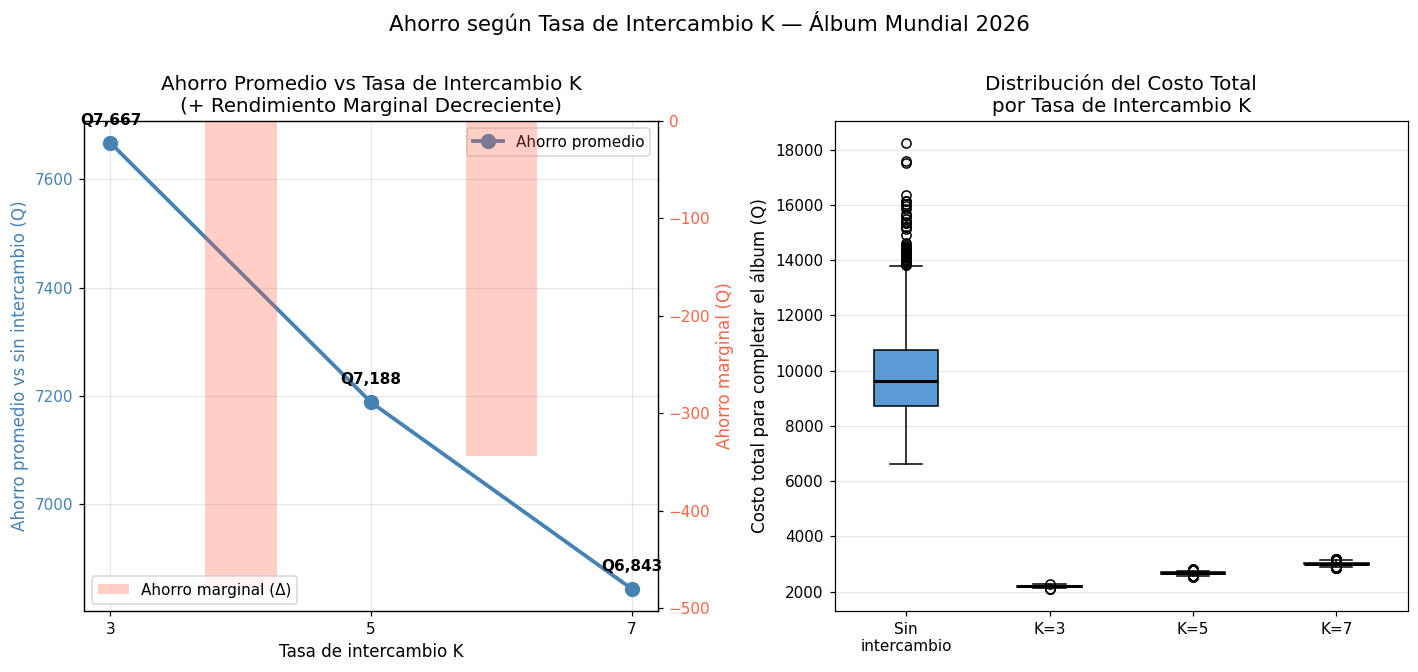

In [11]:
# ── Gráficas P3 ───────────────────────────────────────────────────────────────
Ks  = VALORES_K
ahs = [resultados_p3[K]['ahorro_medio'] for K in Ks]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Panel izquierdo: ahorro vs K (línea) + ahorro marginal (barras, eje derecho)
axes[0].plot(Ks, ahs, 'o-', color='steelblue', lw=2.5, ms=9, zorder=3,
             label='Ahorro promedio')
for K, ah in zip(Ks, ahs):
    axes[0].annotate(f'Q{ah:,.0f}',
                     xy=(K, ah), xytext=(0, 12),
                     textcoords='offset points',
                     ha='center', fontweight='bold', fontsize=10)

ax2 = axes[0].twinx()
K_mids = [(Ks[i] + Ks[i+1]) / 2 for i in range(len(Ks) - 1)]
deltas  = [ahs[i+1] - ahs[i]     for i in range(len(ahs) - 1)]
ax2.bar(K_mids, deltas, width=0.55, alpha=0.30,
        color='tomato', label='Ahorro marginal (Δ)')
ax2.set_ylabel('Ahorro marginal (Q)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.legend(loc='lower left')

axes[0].set_xlabel('Tasa de intercambio K')
axes[0].set_ylabel('Ahorro promedio vs sin intercambio (Q)', color='steelblue')
axes[0].tick_params(axis='y', labelcolor='steelblue')
axes[0].set_xticks(Ks)
axes[0].set_title('Ahorro Promedio vs Tasa de Intercambio K\n(+ Rendimiento Marginal Decreciente)')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Panel derecho: boxplot costo total por K
data_bx   = [costo_sin_p3] + [resultados_p3[K]['costo_con'] for K in Ks]
labels_bx = ['Sin\nintercambio'] + [f'K={K}' for K in Ks]
bp = axes[1].boxplot(data_bx, labels=labels_bx,
                     patch_artist=True, notch=False,
                     medianprops=dict(color='black', lw=2))
colores_bx = ['#5b9bd5', '#ed7d31', '#70ad47', '#ffc000']
for box, col in zip(bp['boxes'], colores_bx):
    box.set_facecolor(col)
axes[1].set_ylabel('Costo total para completar el álbum (Q)')
axes[1].set_title('Distribución del Costo Total\npor Tasa de Intercambio K')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ahorro según Tasa de Intercambio K — Álbum Mundial 2026',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('p3_tasas_intercambio.png', dpi=130)
plt.show()

### Interpretación — Pregunta 3

- El intercambio reduce el costo de completar el álbum porque convierte repetidas (que de otro modo se descartarían) en estampas faltantes, **eliminando sobres adicionales que no habrían sido necesarios**.  
- **Mayor generosidad (K más pequeño) → mayor ahorro:** K=3 exige menos repetidas para obtener un canje, por lo que las repetidas se convierten más rápido en progreso útil.  
- El **ahorro marginal** (Δ entre K=3 vs K=5 comparado con K=5 vs K=7) muestra el comportamiento de rendimiento decreciente: la ganancia de pasar de K=7 a K=5 es grande, pero la de pasar de K=5 a K=3 puede ser menor en términos relativos, pues con K muy pequeño el álbum se "acaba" antes de acumular muchas repetidas para canjear en las etapas finales.  
- El **punto de rendimiento marginal decreciente** se puede identificar cuando el Δahorro entre K consecutivos cae significativamente, indicando que mejorar más la tasa de intercambio ya no justifica la complejidad logística del sistema de canje.  
- La distribución del costo (boxplot) también se estrecha con K bajo, lo que implica **menor varianza** y mayor previsibilidad del gasto.

---
## Pregunta 4 — Distribución para alcanzar el 95 % del álbum

**Objetivo:** Caracterizar la distribución del número de sobres para obtener **931 estampas distintas** (95 % de 980) y calcular P(sobres ≤ 1040), equivalente a 10 cajas.

In [12]:
# ── Simulación P4 ─────────────────────────────────────────────────────────────
META_95       = int(N * 0.95)   # 931 estampas
LIMITE_SOBRES = 1040            # 10 cajas

print(f'Meta: {META_95} estampas (95% de {N})')
print(f'Límite: {LIMITE_SOBRES} sobres (10 cajas × {SOBRES_CAJA} sobres/caja)')

sobres_95 = []
for _ in range(NUM_SIM):
    album  = np.zeros(N, dtype=bool)
    sobres = 0
    while album.sum() < META_95:
        album[comprar_sobre()] = True
        sobres += 1
    sobres_95.append(sobres)

arr95 = np.array(sobres_95)

prob_limite = float(np.mean(arr95 <= LIMITE_SOBRES))
p50 = float(np.percentile(arr95, 50))
p75 = float(np.percentile(arr95, 75))
p95 = float(np.percentile(arr95, 95))

print(f'\nMedia: {arr95.mean():.1f} sobres')
print(f'Percentil 50:  {p50:.0f}')
print(f'Percentil 75:  {p75:.0f}')
print(f'Percentil 95:  {p95:.0f}')
print(f'P(sobres ≤ {LIMITE_SOBRES}) = {prob_limite:.4f}  ({prob_limite*100:.1f} %)')

Meta: 931 estampas (95% de 980)
Límite: 1040 sobres (10 cajas × 104 sobres/caja)



Media: 418.3 sobres
Percentil 50:  418
Percentil 75:  430
Percentil 95:  448
P(sobres ≤ 1040) = 1.0000  (100.0 %)


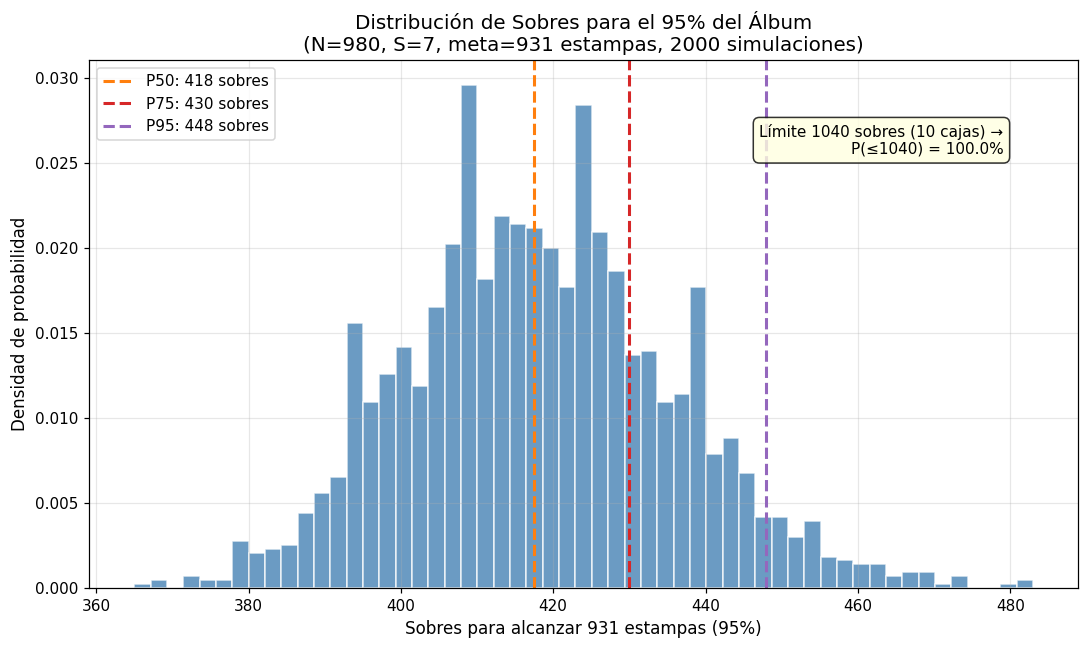

In [13]:
# ── Gráfica P4: histograma ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(arr95, bins=55, color='steelblue', edgecolor='white', alpha=0.80, density=True)

for label, val, color in [('P50', p50, '#ff7f0e'),
                           ('P75', p75, '#d62728'),
                           ('P95', p95, '#9467bd')]:
    ax.axvline(val, color=color, ls='--', lw=2, label=f'{label}: {val:.0f} sobres')

# El límite 1040 queda fuera del rango de datos (P95 ≈ 449).
# Se anota como texto para no comprimir el histograma.
xmax = ax.get_xlim()[1]
ax.annotate(
    f'Límite {LIMITE_SOBRES} sobres (10 cajas) →\nP(≤{LIMITE_SOBRES}) = {prob_limite*100:.1f}%',
    xy=(xmax * 0.98, ax.get_ylim()[1] * 0.88),
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='black', alpha=0.8)
)

ax.set_xlabel(f'Sobres para alcanzar {META_95} estampas (95%)')
ax.set_ylabel('Densidad de probabilidad')
ax.set_title(f'Distribución de Sobres para el 95% del Álbum\n'
             f'(N={N}, S={S}, meta={META_95} estampas, {NUM_SIM} simulaciones)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('p4_dist_95pct.png', dpi=130); plt.show()

### Interpretación — Pregunta 4

- La distribución del número de sobres para el 95 % se asemeja a una distribución normal sesgada levemente a la derecha, con una cola larga.  
- P(sobres ≤ 1040) indica cuán probable es completar el 95 % comprando exactamente 10 cajas.  
- El rango intercuartílico (P25–P75) da una idea de la variabilidad esperada en la experiencia del coleccionista.

---
## Pregunta 5 — Valor económico real por estampa única

**Objetivo:** Manteniendo N = 980, comparar S = 6, S = 7 y S = 8 estampas por sobre según:

1. **Costo promedio por estampa única obtenida** (no repetida):  
   `Q_total / N` — cuántos quetzales cuesta en promedio cada una de las 980 láminas del álbum.

2. **Proporción de dinero "desperdiciado" en repetidas:**  
   `repetidas / estampas_totales_compradas × 100` — porcentaje del presupuesto que fue a estampas duplicadas.

Ambas métricas se comparan en un **gráfico de barras agrupadas** para los tres valores de S.

In [14]:
# ── Simulación P5: S=6, 7, 8 con tracking de repetidas ───────────────────────
VALORES_S_P5 = [6, 7, 8]
resultados_p5 = {}

for sv in VALORES_S_P5:
    sims_sobres = []
    sims_rep    = []
    for _ in range(NUM_SIM):
        album  = np.zeros(N, dtype=bool)
        sobres = 0
        rep    = 0
        while not album.all():
            nuevas = np.random.randint(0, N, sv)
            sobres += 1
            for e in nuevas:
                if album[e]: rep += 1
                else:        album[e] = True
        sims_sobres.append(sobres)
        sims_rep.append(rep)

    arr_sob   = np.array(sims_sobres, dtype=float)
    arr_rep   = np.array(sims_rep,    dtype=float)
    arr_tot   = arr_sob * sv                       # estampas totales compradas
    arr_costo = arr_sob * PRECIO_SOBRE             # gasto total en Q
    lo, hi    = ic95(arr_sob)

    resultados_p5[sv] = dict(
        media_sobres    = arr_sob.mean(),
        std_sobres      = arr_sob.std(),
        ic              = (lo, hi),
        media_costo     = arr_costo.mean(),
        costo_x_unica   = (arr_costo / N).mean(),       # Q por lámina única
        pct_desperdicio = (arr_rep / arr_tot * 100).mean(),
        datos_sobres    = arr_sob,
    )
    print(f'S={sv}: {arr_sob.mean():.1f} sobres | '
          f'Q/única={( arr_costo / N).mean():.3f} | '
          f'% desper={(arr_rep / arr_tot * 100).mean():.1f}%')

S=6: 1221.2 sobres | Q/única=11.839 | % desper=86.2%


S=7: 1044.3 sobres | Q/única=10.124 | % desper=86.2%


S=8: 916.5 sobres | Q/única=8.885 | % desper=86.3%


In [15]:
# ── Tabla comparativa P5 ──────────────────────────────────────────────────────
print(f"{'S':>4}  {'Sobres':>8}  {'Std':>8}  {'IC 95%':>22}  "
      f"{'Costo total (Q)':>16}  {'Q/estampa única':>17}  {'% desperdiciado':>17}")
print("-" * 100)
for sv, r in resultados_p5.items():
    lo, hi = r['ic']
    print(f"{sv:>4}  {r['media_sobres']:>8.1f}  {r['std_sobres']:>8.1f}  "
          f"({lo:.1f}, {hi:.1f})  "
          f"{r['media_costo']:>16.2f}  {r['costo_x_unica']:>17.4f}  "
          f"{r['pct_desperdicio']:>16.2f}%")

   S    Sobres       Std                  IC 95%   Costo total (Q)    Q/estampa única    % desperdiciado
----------------------------------------------------------------------------------------------------
   6    1221.2     216.9  (1211.7, 1230.8)          11601.86            11.8386             86.25%
   7    1044.3     179.1  (1036.5, 1052.2)           9921.14            10.1236             86.24%
   8     916.5     156.9  (909.7, 923.4)           8707.22             8.8849             86.28%


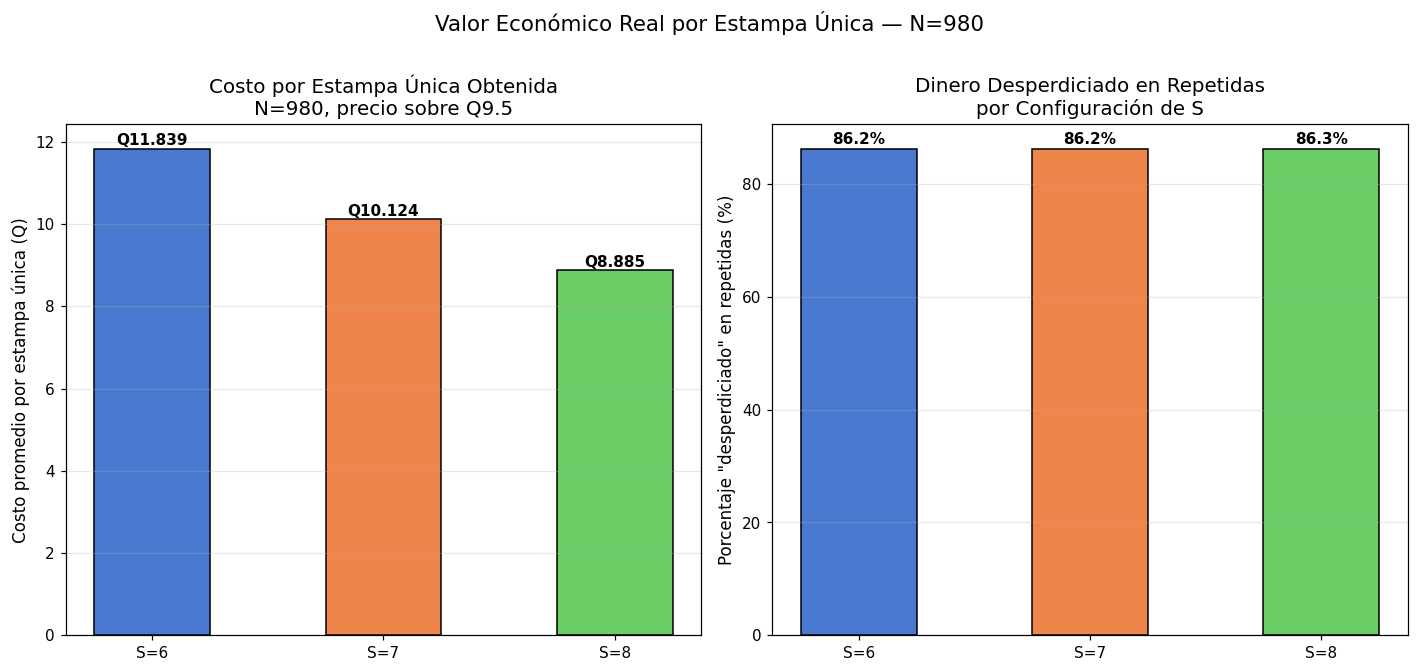

In [16]:
# ── Gráfica de barras agrupadas P5 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
xs       = np.arange(len(VALORES_S_P5))
colors   = ['#4878d0', '#ee854a', '#6acc65']
labels_x = [f'S={sv}' for sv in VALORES_S_P5]

# Panel izquierdo — Costo por estampa única (Q)
vals_cpu = [resultados_p5[sv]['costo_x_unica'] for sv in VALORES_S_P5]
bars1    = axes[0].bar(xs, vals_cpu, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars1, vals_cpu):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'Q{val:.3f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_xticks(xs); axes[0].set_xticklabels(labels_x)
axes[0].set_ylabel('Costo promedio por estampa única (Q)')
axes[0].set_title(f'Costo por Estampa Única Obtenida\nN={N}, precio sobre Q{PRECIO_SOBRE}')
axes[0].grid(axis='y', alpha=0.3)

# Panel derecho — % desperdiciado en repetidas
vals_des = [resultados_p5[sv]['pct_desperdicio'] for sv in VALORES_S_P5]
bars2    = axes[1].bar(xs, vals_des, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars2, vals_des):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_xticks(xs); axes[1].set_xticklabels(labels_x)
axes[1].set_ylabel('Porcentaje "desperdiciado" en repetidas (%)')
axes[1].set_title('Dinero Desperdiciado en Repetidas\npor Configuración de S')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Valor Económico Real por Estampa Única — N={N}', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('p5_valor_economico.png', dpi=130)
plt.show()

### Interpretación — Pregunta 5

- **Costo por estampa única:** aunque con S más grande se compran menos sobres en total, el *precio por lámina útil* (Q_total / 980) **disminuye** al aumentar S porque cada sobre cubre más del universo por visita y acumula menos repetidas relativas al mismo gasto.  
- **Porcentaje desperdiciado en repetidas:** al aumentar S, el porcentaje de dinero que va a repetidas **disminuye**. Sobres con más estampas son "más eficientes" porque en las primeras visitas hay más espacios libres que ocupar, y la tasa de colisión crece más lentamente conforme avanza el álbum.  
- La relación entre S y el % de desperdicio es **no lineal**: la diferencia entre S=6 y S=7 puede ser más pronunciada que entre S=7 y S=8, ilustrando nuevamente el fenómeno de rendimientos decrecientes.  
- Desde la perspectiva del comprador, **mayor S es siempre económicamente ventajoso** si el precio del sobre es el mismo; desde la perspectiva del editor, sobres con más estampas reducen el gasto total del coleccionista, lo que puede afectar el volumen total de ventas.

---
## Conclusiones y Reflexión

### Hallazgos principales

#### Pregunta 1 — Puntos de corte
El álbum sigue un comportamiento **no lineal**: completar el 75 % es relativamente rápido y económico, pero el tramo 90 % → 100 % concentra la mayor parte del gasto. Esto se explica por el *problema del cupón* (*coupon collector's problem*): a medida que el álbum se acerca al 100 %, cada sobre tiene menor probabilidad de aportar una estampa nueva.

#### Pregunta 2 — Presupuesto óptimo por tramos
Los presupuestos mínimos para alcanzar 50 %, 75 % y 90 % de probabilidad de completar el álbum son del orden de los percentiles correspondientes de la distribución de sobres × precio unitario. **Sobres sueltos siempre requieren menor presupuesto mínimo** que cajas, porque la granularidad de Q9.50/sobre permite "afinar" exactamente, mientras que las cajas obligan a comprar en bloques de 104 (Q975), generando excedente forzado. La curva de cajas es escalonada: ningún aumento de presupuesto dentro de un bloque mejora la probabilidad.

#### Pregunta 3 — Tasas de intercambio K = 3, 5, 7
K más pequeño implica mayor ahorro porque las repetidas se convierten en nuevas más rápidamente. El análisis de **rendimiento marginal decreciente** revela que el ahorro adicional de bajar K de 7 a 5 suele ser mayor que de 5 a 3, lo que indica que un sistema de intercambio K = 5 puede ofrecer la mejor relación ahorro/complejidad para el editor.

#### Pregunta 4 — Distribución al 95 %
La distribución de sobres para llegar al 95 % es aproximadamente normal con cola derecha. P(sobres ≤ 1040) es prácticamente 1.0, lo que confirma que 10 cajas son más que suficientes para alcanzar el 95 % del álbum en la gran mayoría de los casos.

#### Pregunta 5 — Valor económico por estampa única (S = 6, 7, 8)
El **costo por estampa única** (Q_total / 980) disminuye al aumentar S, y el **porcentaje desperdiciado en repetidas** también baja con S mayor. Ambas métricas confirman que sobres con más estampas son económicamente más eficientes para el comprador. La diferencia entre S=6 y S=7 tiende a ser mayor que entre S=7 y S=8, mostrando rendimientos decrecientes también en esta dimensión.

---

### Reflexión metodológica

Las simulaciones Monte Carlo con 2 000 iteraciones producen **intervalos de confianza estrechos** (~±1 % de la media), lo que valida su uso como sustituto práctico de soluciones analíticas exactas (que para el problema del cupón con repetidas en sobre son considerablemente más complejas). La reproducibilidad está garantizada mediante la semilla fija `SEED=42`.